In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_ebay_deals.csv")
df.head()

,timestamp,title,price,original_price,shipping,item_url,discount_percentage
0,2026-03-11 04:22:33,"Sony Xperia 10 IV 5G XQ-CC54 128GB 6.0"" Androi...",171.58,171.58,Free shipping,NaN,0.0
1,2026-03-11 04:22:33,Nokia 1209 - Midnight Blue (Unlocked) Cellular...,36.97,36.97,Free shipping,NaN,0.0
2,2026-03-11 04:22:33,Cartine Rizla Liquorice Corte – Gusto Naturale...,35.94,35.94,Free shipping,NaN,0.0
3,2026-03-11 04:22:33,Honor Magic V 5G 512GB Google Android 12 Snapd...,540.76,540.76,Free shipping,NaN,0.0
4,2026-03-11 04:22:33,NaN,NaN,NaN,Shipping info unavailable,NaN,NaN


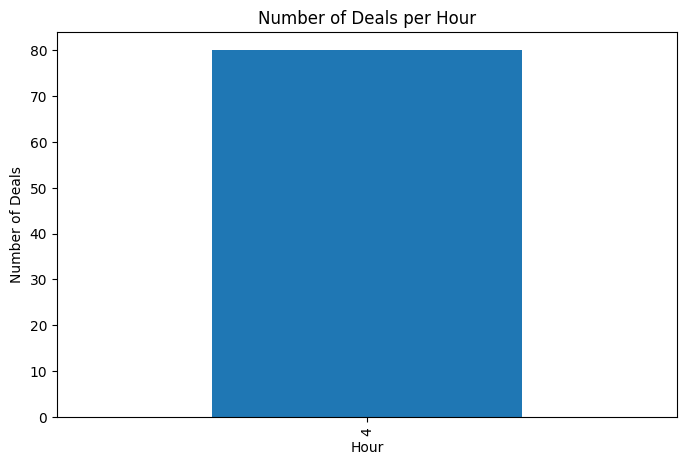

In [2]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.sort_values("timestamp")
df["hour"] = df["timestamp"].dt.hour

hour_counts = df.groupby("hour").size()

plt.figure(figsize=(8,5))
hour_counts.plot(kind="bar")
plt.title("Number of Deals per Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Deals")
plt.show()

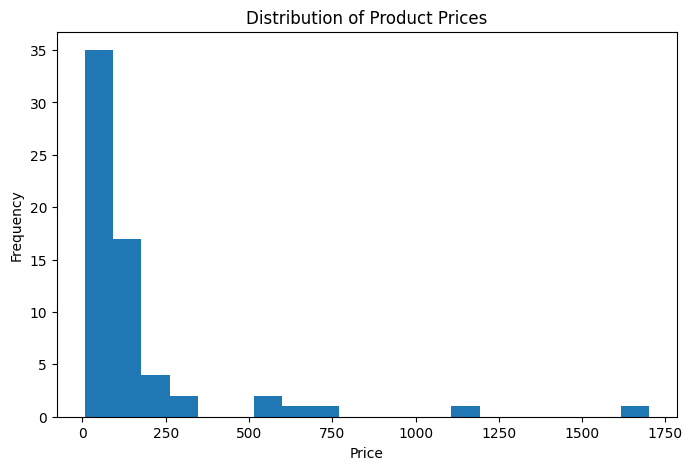

In [3]:
plt.figure(figsize=(8,5))
df["price"].dropna().plot(kind="hist", bins=20)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.show()

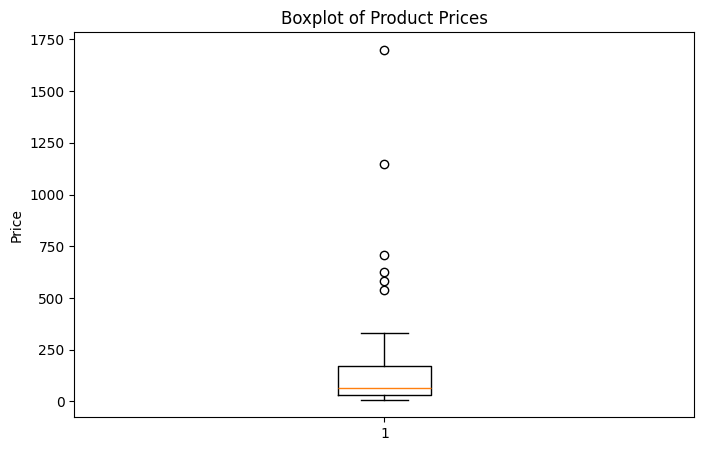

In [4]:
plt.figure(figsize=(8,5))
plt.boxplot(df["price"].dropna())
plt.title("Boxplot of Product Prices")
plt.ylabel("Price")
plt.show()

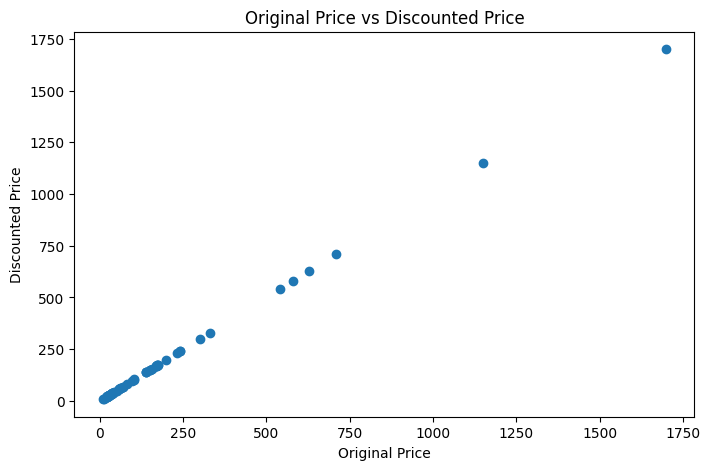

In [5]:
plt.figure(figsize=(8,5))
plt.scatter(df["original_price"], df["price"])
plt.title("Original Price vs Discounted Price")
plt.xlabel("Original Price")
plt.ylabel("Discounted Price")
plt.show()

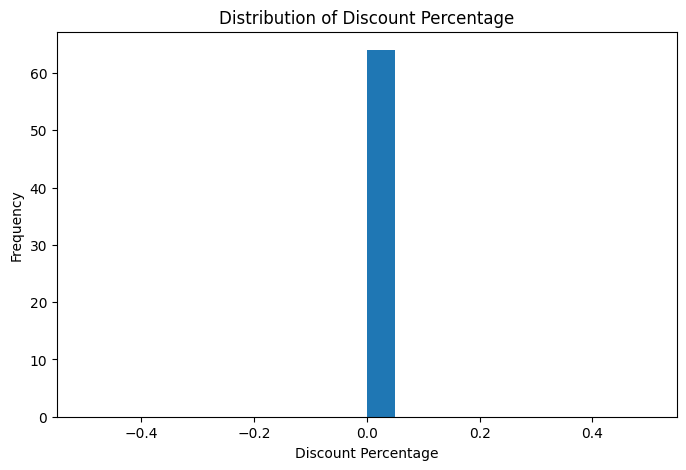

In [6]:
plt.figure(figsize=(8,5))
df["discount_percentage"].dropna().plot(kind="hist", bins=20)
plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount Percentage")
plt.show()

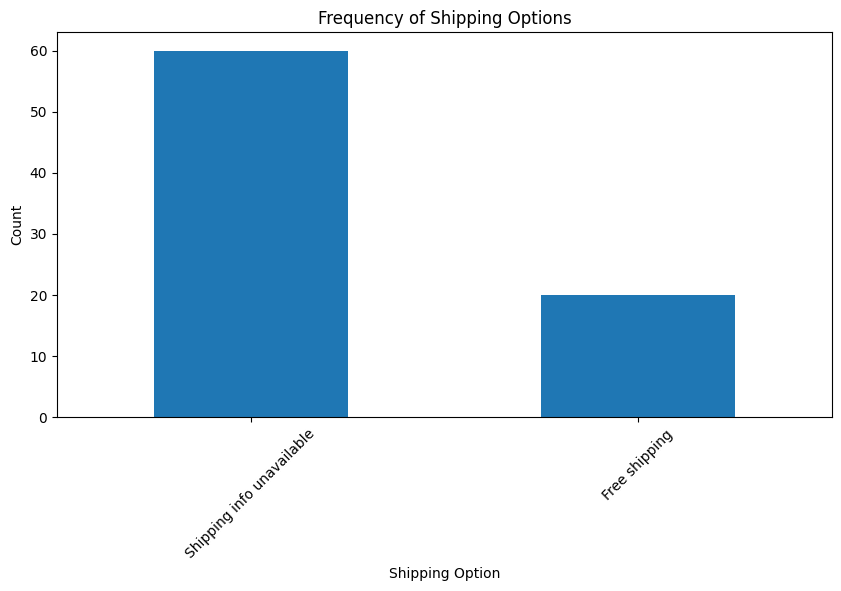

In [7]:
shipping_counts = df["shipping"].value_counts()

plt.figure(figsize=(10,5))
shipping_counts.plot(kind="bar")
plt.title("Frequency of Shipping Options")
plt.xlabel("Shipping Option")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

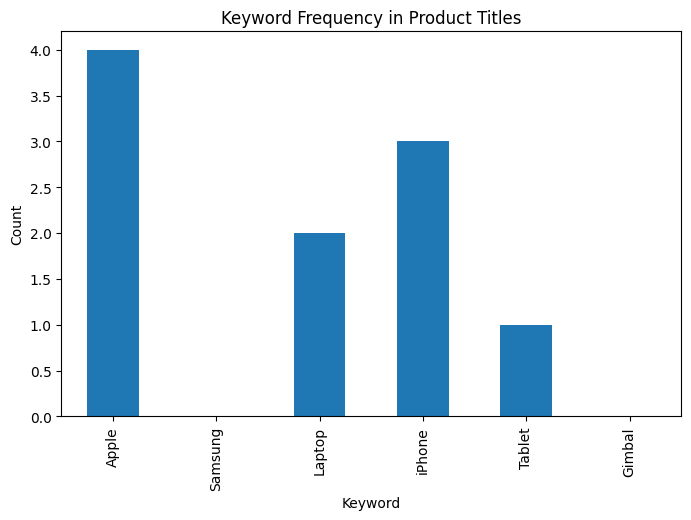

In [8]:
keywords = ["Apple", "Samsung", "Laptop", "iPhone", "Tablet", "Gimbal"]

keyword_counts = {}
for keyword in keywords:
    keyword_counts[keyword] = df["title"].str.contains(keyword, case=False, na=False).sum()

keyword_series = pd.Series(keyword_counts)

plt.figure(figsize=(8,5))
keyword_series.plot(kind="bar")
plt.title("Keyword Frequency in Product Titles")
plt.xlabel("Keyword")
plt.ylabel("Count")
plt.show()

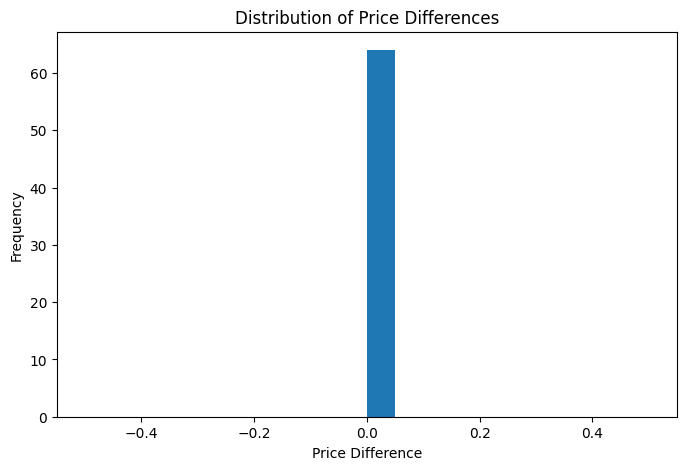

In [9]:
df["price_difference"] = df["original_price"] - df["price"]

plt.figure(figsize=(8,5))
df["price_difference"].dropna().plot(kind="hist", bins=20)
plt.title("Distribution of Price Differences")
plt.xlabel("Price Difference")
plt.show()

In [10]:
top5 = df.sort_values("discount_percentage", ascending=False).head(5)
top5[["title", "price", "original_price", "discount_percentage"]]

,title,price,original_price,discount_percentage
0,"Sony Xperia 10 IV 5G XQ-CC54 128GB 6.0"" Androi...",171.58,171.58,0.0
57,NEW Apple iPod Classic 5th 6th 7th Generation ...,173.00,173.00,0.0
56,Jensen Transformers CI-2MINI Hum/Buzz Eliminat...,239.99,239.99,0.0
55,AM Transmitter - Stream to Your Vintage Tube R...,49.95,49.95,0.0
53,CANON RF-S10-18mm F4.5-6.3 IS STM Ultra Wide Z...,167.20,167.20,0.0


In [11]:
import os
print(os.listdir())

['.git', '.github', '.vscode', 'cleaned_ebay_deals.csv', 'clean_data.py', 'ebay_tech_deals.csv', 'EDA.ipynb', 'README.md', 'requirements.txt', 'scraper.py']
